In [2]:
require(data.table)
require(tidyverse)
require(dplyr)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)
options(repr.plot.width=20, repr.plot.height=15)

In [3]:
track1=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run1_Seqnums_16S.csv")

track2=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_Seqnums_16S.csv")

track3=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run3_Seqnums_16S.csv")

track4=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run4_Seqnums_16S.csv")

track5=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run5_Seqnums_16S.csv")

In [4]:
track <- bind_rows(track1, track2, track3, track4, track5)

In [5]:
asv1=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run1_16S_ASV_nochim.csv")

asv2=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_16S_ASV_nochim.csv")

asv3=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run3_16S_ASV_nochim.csv")

asv4=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run4_16S_ASV_nochim.csv")

asv5=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run5_16S_ASV_nochim.csv")

In [6]:
asv <- bind_rows(asv1, asv2, asv3, asv4, asv5)

In [7]:
taxa1=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run1_16S_taxa.csv", header=TRUE, row.names=1)

taxa2=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_16S_taxa.csv", header=TRUE, row.names=1)

taxa3=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run3_16S_taxa.csv", header=TRUE, row.names=1)

taxa4=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run4_16S_taxa.csv", header=TRUE, row.names=1)

taxa5=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run5_16S_taxa.csv", header=TRUE, row.names=1)

In [8]:
taxa <- bind_rows(taxa1, taxa2, taxa3, taxa4, taxa5)

In [9]:
meta=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/meta_PCR.csv", header=TRUE)

In [10]:
head(taxa)

,Kingdom,Phylum,Class,Order,Family,Genus
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG...1,Bacteria,Pseudomonadota,Alphaproteobacteria,NA,NA,NA
GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG...2,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Vibrionaceae,Vibrio
GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG...3,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Endozoicomonadaceae,Parendozoicomonas
GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG...4,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhodospirillales,Terasakiellaceae,Marivibrio
GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG...5,Bacteria,Pseudomonadota,Alphaproteobacteria,NA,NA,NA
GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG...6,Bacteria,Cyanobacteriota,Cyanobacteriia,Chloroplast,NA,NA


In [11]:
head(track)

V1,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
012024-BEL-CBC-T1-557-SSID,140907,132539,130818,130771,127036,118800
012024-BEL-CBC-T1-563-PSTR,97665,89798,89392,89308,88670,48116
012024-BEL-CBC-T2-601-OFAV,263467,250569,249704,249707,248016,191585
012024-BEL-CBC-T2-605-SSID,605361,574264,571735,571551,564520,517961
012024-BEL-CBC-T3-627-PAST,1656969,1561240,1540358,1539923,1487115,1323604
012024-BEL-CBC-T3-631-MCAV,513353,484960,483847,483931,476841,424109


In [12]:
nrow(track)

[1] 484

In [13]:

#look at how many reads per sample, are there any samples needed to exclude
# dig into Date_16S
## post dada2 (before making ps object)- distribution of read lengths are the same (specif for Date_16S)
### track df
# rerun post phyloseq 

## post dada2 16S figures to find what data we are working with
### reads distributed (across samples, spec, Health_status, seq_run, Month_year)

In [14]:
setnames(track, c("V1"), c("Tubelabel_species"), skip_absent=TRUE)
# Step 1: Replace '-' with '_' in asv_clean$Tube
track$Tubelabel_species <- gsub("-", "_", track$Tubelabel_species)
head(track)

Tubelabel_species,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
012024_BEL_CBC_T1_557_SSID,140907,132539,130818,130771,127036,118800
012024_BEL_CBC_T1_563_PSTR,97665,89798,89392,89308,88670,48116
012024_BEL_CBC_T2_601_OFAV,263467,250569,249704,249707,248016,191585
012024_BEL_CBC_T2_605_SSID,605361,574264,571735,571551,564520,517961
012024_BEL_CBC_T3_627_PAST,1656969,1561240,1540358,1539923,1487115,1323604
012024_BEL_CBC_T3_631_MCAV,513353,484960,483847,483931,476841,424109


In [15]:
#exclude samples that are not in asv_clean
track_meta <- merge(meta, track, by = "Tubelabel_species", all = FALSE)

In [16]:
head(track_meta)

Tubelabel_species,X,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,⋯,Date_16S,Date_ITS2,Seq_run,Transect,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
012024_BEL_CBC_T1_557_SSID,1,2_17_2025,44.6,,,12024,1_3,1/10/24,SSID,⋯,3_4_2025,7_7_2025,1,CBC30N,140907,132539,130818,130771,127036,118800
012024_BEL_CBC_T1_559_MCAV,2,2_17_2025,14.8,,,12024,1_24,1/10/24,MCAV,⋯,8_22_2025,12_15_2025,2,CBC30N,1377610,1219878,1217341,1217659,1205749,206754
012024_BEL_CBC_T1_561_OANN,3,2_17_2025,18,,,12024,1_25,1/10/24,OANN,⋯,1_9_2026,1_21_2026,3,CBC30N,5678,3850,3576,3504,2767,765
012024_BEL_CBC_T1_563_PSTR,4,2_17_2025,35.8,,,12024,1_12,1/10/24,PSTR,⋯,3_6_2025,7_7_2025,1,CBC30N,97665,89798,89392,89308,88670,48116
012024_BEL_CBC_T1_565_PAST,5,2_17_2025,7.72,,,12024,1_21,1/10/24,PAST,⋯,2_10_2026,2_17_2026,4,CBC30N,1214900,1099381,1088713,1087483,1029696,774055
012024_BEL_CBC_T2_585_OFAV,6,2_17_2025,71.6,,,12024,2_76,1/12/24,OFAV,⋯,2_10_2026,2_17_2026,4,SR30N,627001,565773,561251,564167,548455,350149


In [24]:
#standard deviation measures the dispersion of this data set relative to the mean
sd(track_meta$nonchim, na.rm = FALSE)

[1] 594013.5

In [25]:
mean(track_meta$nonchim)

[1] 353342.1

In [26]:
median(track_meta$nonchim)

[1] 260602

In [ ]:
## ANOVA test hypotheses:
- Null hypothesis: the means of the different groups are the same
- Alternative hypothesis: At least one sample mean is not equal to the others

In [36]:
# Compute the analysis of variance
nonchim.anov <- aov(nonchim ~ Date_16S + factor(Month_year) + Seq_run + Species + Health_status, data = track_meta)
# Summary of the analysis
summary(nonchim.anov)


                    Df    Sum Sq   Mean Sq F value   Pr(>F)    
Date_16S            29 3.852e+13 1.328e+12   4.744 1.64e-13 ***
factor(Month_year)  11 4.410e+12 4.009e+11   1.432  0.15553    
Seq_run              1 5.574e+10 5.574e+10   0.199  0.65570    
Species              5 4.420e+12 8.839e+11   3.157  0.00825 ** 
Health_status        3 6.924e+11 2.308e+11   0.824  0.48101    
Residuals          423 1.184e+14 2.800e+11                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [38]:
batch.anov <- aov(nonchim ~ Date_16S + factor(Seq_run), data = track_meta)
summary(batch.anov)

                 Df    Sum Sq   Mean Sq F value   Pr(>F)    
Date_16S         29 3.852e+13 1.328e+12   4.589 5.33e-13 ***
factor(Seq_run)   1 7.959e+10 7.959e+10   0.275      0.6    
Residuals       442 1.279e+14 2.895e+11                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [34]:
#why are degrees of freedom= 1 for Month_year and Seq_run?
## when I use to factor(Month_year) I see the correct Df
length(unique(track_meta$Month_year))
length(unique((track_meta$Seq_run)))
length(unique((track_meta$Date_16S)))

[1] 12

[1] 5

[1] 30

In [18]:
#wider plots
#making plots small 
options(repr.plot.width = 25, repr.plot.height = 8)

In [ ]:
## plot nochim reads vs Daet_16S

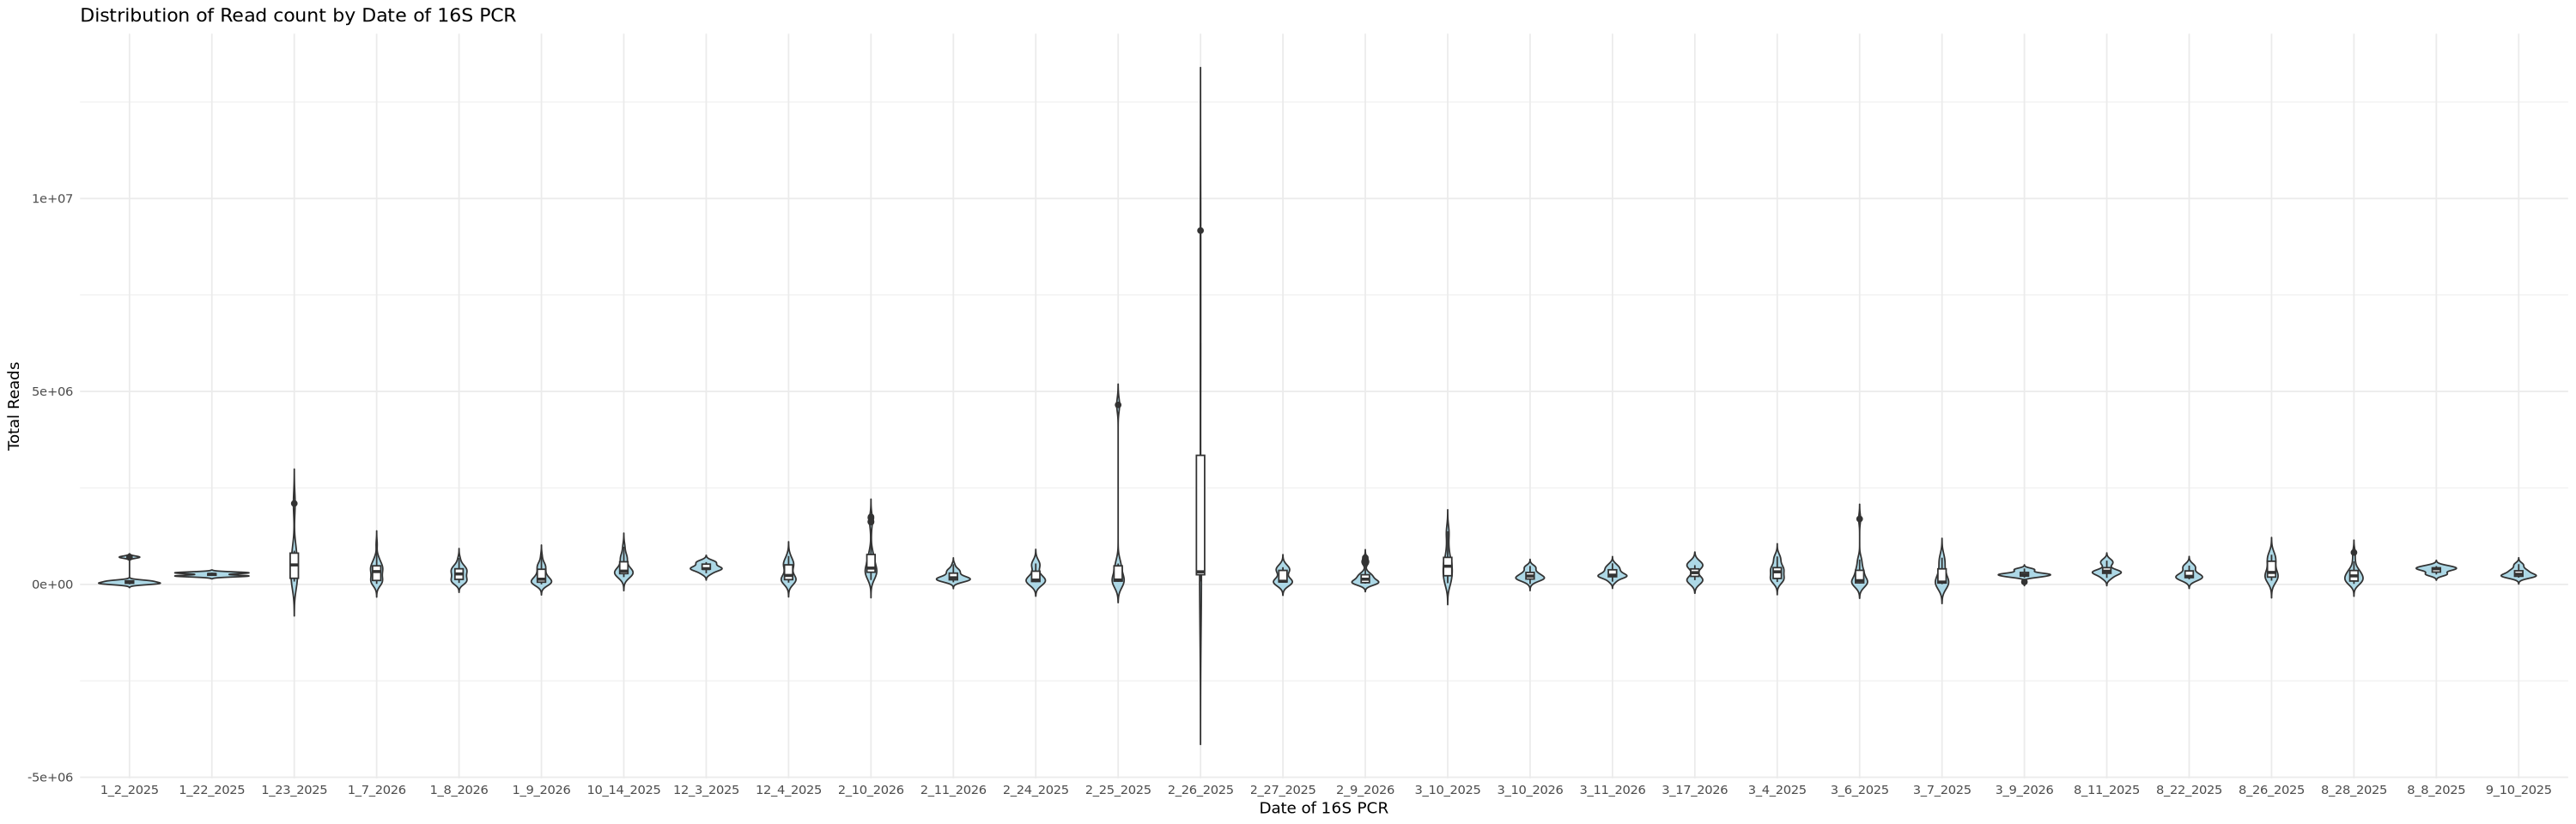

In [22]:
#using a violin plot to visualize the distribution of length of reads (y) and y or no double banding (x)
ggplot(track_meta, aes(x = factor(Date_16S), y = nonchim)) +
  geom_violin(trim = FALSE, fill = "lightblue") +
  geom_boxplot(width = 0.1) +
  labs(x = "Date of 16S PCR", y = "Total Reads",
       title = "Distribution of Read count by Date of 16S PCR") +
  theme_minimal()

In [ ]:
## plot nochim reads vs seq run  

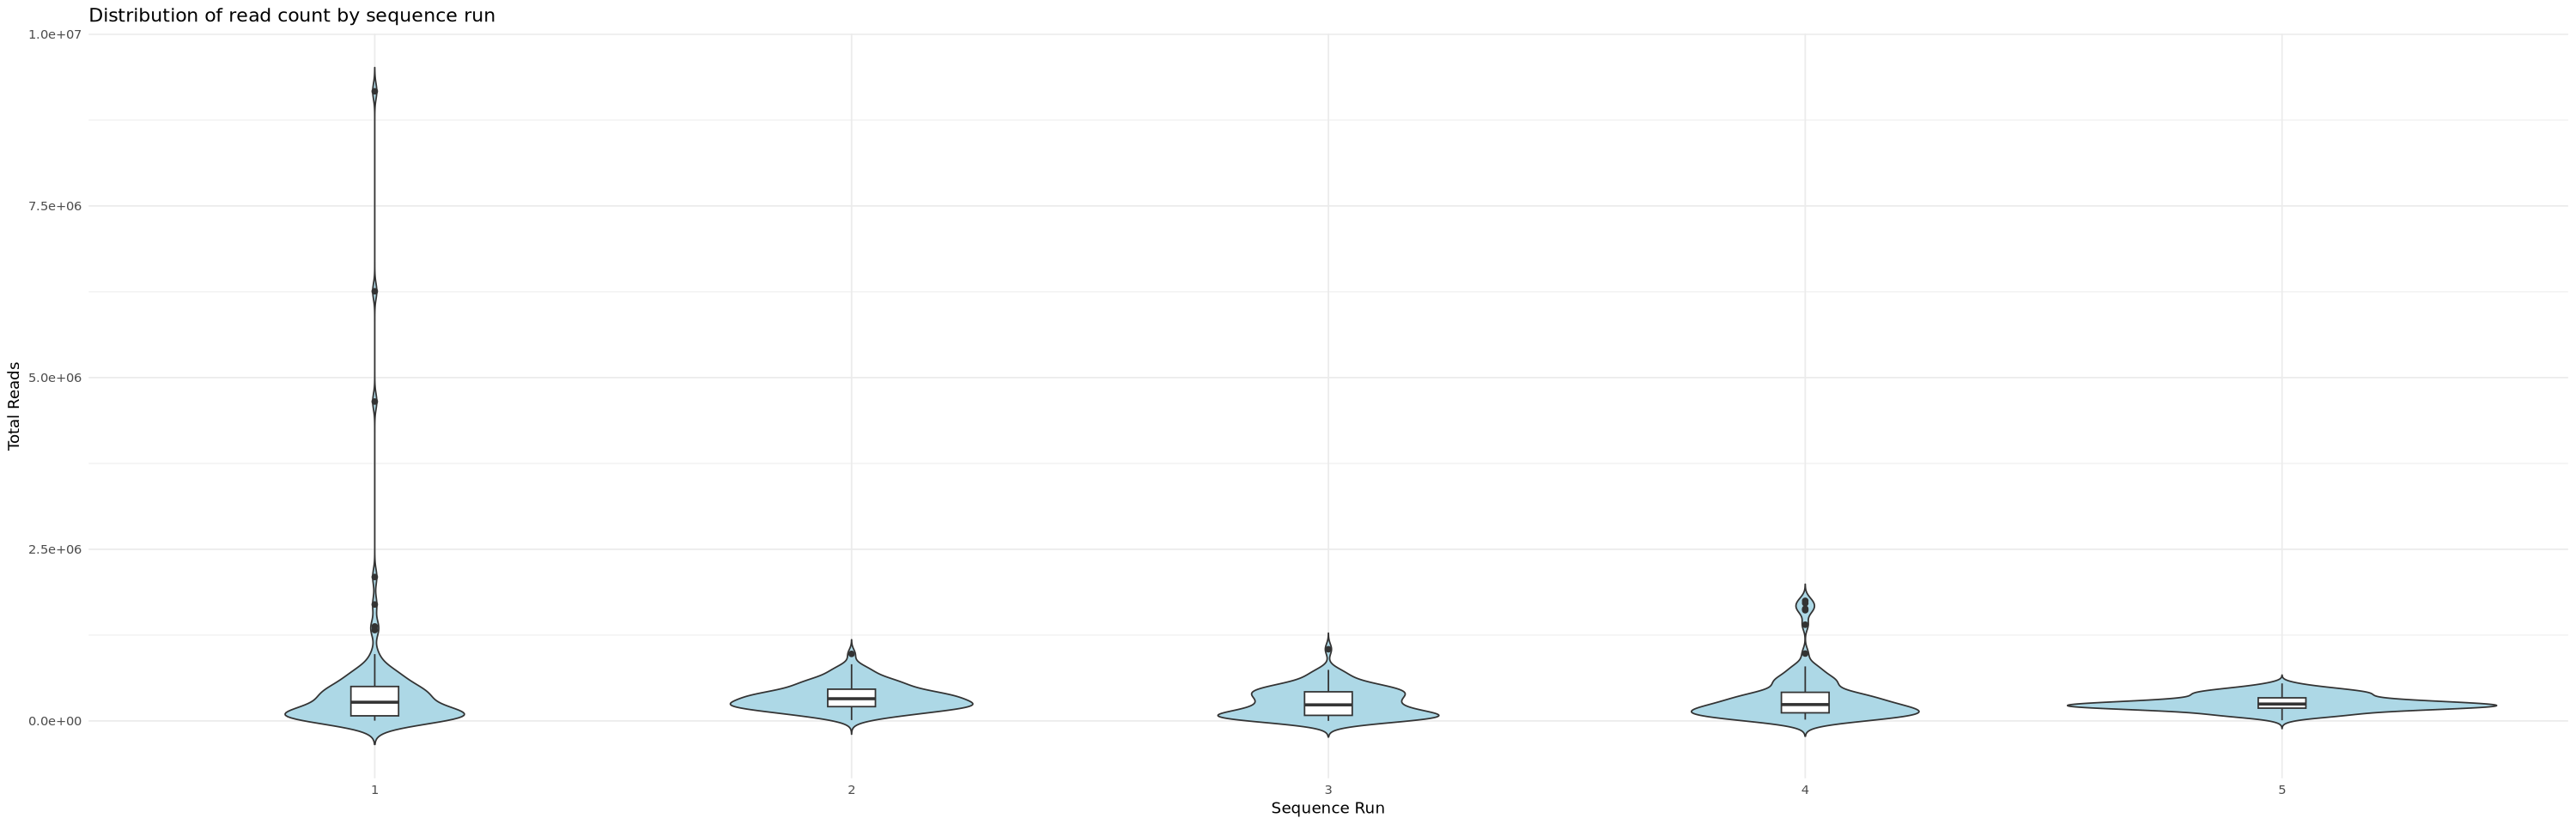

In [20]:
#using a violin plot to visualize the distribution of length of reads (y) and y or no double banding (x)
ggplot(track_meta, aes(x = factor(Seq_run), y = nonchim)) +
  geom_violin(trim = FALSE, fill = "lightblue") +
  geom_boxplot(width = 0.1) +
  labs(x = "Sequence Run", y = "Total Reads",
       title = "Distribution of read count by sequence run") +
  theme_minimal()

In [ ]:
## what is driving number of nonchimera reads
#this one is species within transect with date as another variable
adonis2(vegdist(otu_nomit, method = "bray") ~ Date_16S + Month_year + Seq_run + Species + Health_status, data = sample_nomit)


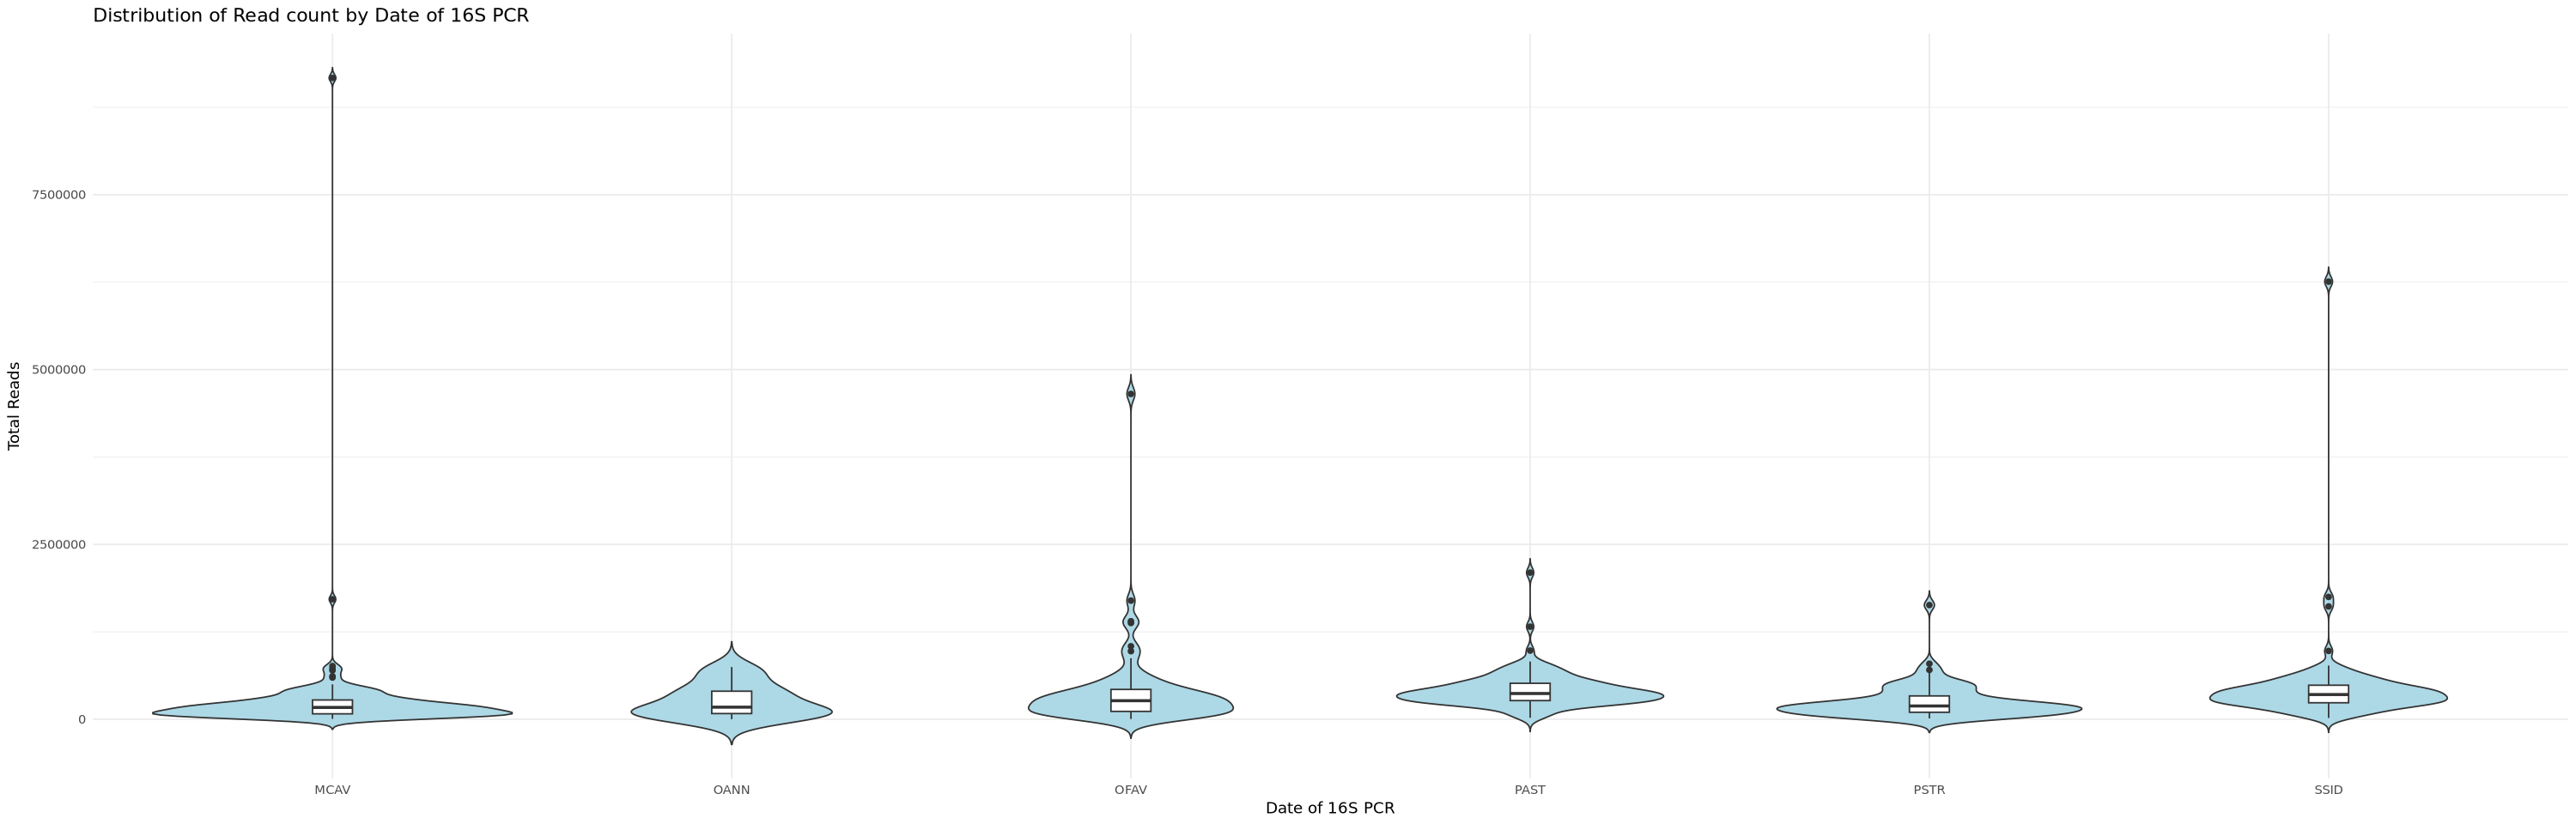

In [23]:
## new data frame 
